![picture](https://drive.google.com/uc?id=1-xuFvbmPE2Y8fTaRaBblI4ghFmRfG7Bs)

1. Selenium
2. BeautifulSoup

In [1]:
!pip install newspaper3k

     |████████████████████████████████| 215kB 3.5MB/s 
     |████████████████████████████████| 51kB 8.0MB/s 
     |████████████████████████████████| 194kB 50.7MB/s 
     |████████████████████████████████| 7.4MB 42.0MB/s 
  Created wheel for feedparser: filename=feedparser-5.2.1-cp36-none-any.whl size=44940 sha256=4d25f1c9d22a62298a2e65d68ce29e6a82419cc99363cca315097f05e5485bc3
  Stored in directory: /root/.cache/pip/wheels/8c/69/b7/f52763c41c5471df57703a0ef718a32a5e81ee35dcf6d4f97f
  Created wheel for feedfinder2: filename=feedfinder2-0.0.4-cp36-none-any.whl size=3357 sha256=4fe781cdccfc904b6e5c7fe23d4d0eaa4f8b4c392ef8ea3c247a1385e13a1832
  Stored in directory: /root/.cache/pip/wheels/de/03/ca/778e3a7a627e3d98836cc890e7cb40c7575424cfd3340f40ed
  Created wheel for tinysegmenter: filename=tinysegmenter-0.3-cp36-none-any.whl size=13539 sha256=91a5bf148dc2fa94298aad0807d8585a9b08373be38dce3aef76f18812c0a881
  Stored in directory: /root/.cache/pip/wheels/81/2b/43/a02ede72324dd40cdd7ca53aad7

In [0]:
import newspaper
from newspaper import Article

In [3]:
url = "https://www.ayobandung.com/read/2020/03/14/82565/who-desak-indonesia-lebih-serius-hadapi-penyebaran-virus-corona"
article = Article(url) #mengambil data artikel
article.download()
article.parse() #parsing
txt = article.text 
txt = txt.encode('ascii', 'ignore').decode("utf-8")
print(txt)

JAKARTA, AYOBANDUNG.COM -- Organisasi Kesehatan Dunia (WHO) mengirim surat resmi kepada Presiden Joko Widodo (Jokowi). Surat yang ditandatangani oleh Direktur Jenderal WHO Tedros Adhanom-Ghebreyesus tertanggal 10 Maret 2020 itu berisi desakan agar pemerintah Indonesia menyeriusi penanganan pandemi Covid-19 oleh virus corona ini. Bahkan WHO meminta Jokowi segera menetapkan status darurat nasional terkait penyebaran Covid-19.

Dalam surat tersebut, Tedros menyebutkan setiap negara perlu mengambil rancangan yang kuat dan terukur untuk mengurangi penularan virus korona ini. Sayangnya, ujar Tedros, WHO melihat ada kasus tak terdeteksi dalam tahap awal penyebaran wabah ini yang berujung pada peningkatan jumlah kasus dan kematian secara signifikan di beberapa negara.

WHO pun mendorong setiap negara untuk fokus pada pendeteksian kasus dan meningkatkan kapasitas uji laboratorium untuk memastikan kasus positif Covid-19. "Ini perlu dilakukan terutama di negara dengan populasi yang besar dan kema

###Preprocessing The Article

In [0]:
import re, string, unicodedata

def cleaning(str):
    #remove non-ascii
    str = unicodedata.normalize('NFKD', str).encode('ascii', 'ignore').decode('utf-8', 'ignore')
    #remove URLs
    str = re.sub(r'(?i)\b((?:https?://|www\d{0,3}[.]|[a-z0-9.\-]+[.][a-z]{2,4}/)(?:[^\s()<>]+|\(([^\s()<>]+|(\([^\s()<>]+\)))*\))+(?:\(([^\s()<>]+|(\([^\s()<>]+\)))*\)|[^\s`!()\[\]{};:\'".,<>?«»“”‘’]))', '', str)
    #remove punctuations
    str = re.sub(r'[^\w]|_',' ',str)
    #remove digit from string
    str = re.sub("\S*\d\S*", "", str).strip()
    #remove digit or numbers
    str = re.sub(r"\b\d+\b", " ", str)
    #to lowercase
    str = str.lower()
    #Remove additional white spaces
    str = re.sub('[\s]+', ' ', str)
    
    return str

In [0]:
clean_txt = cleaning(txt)

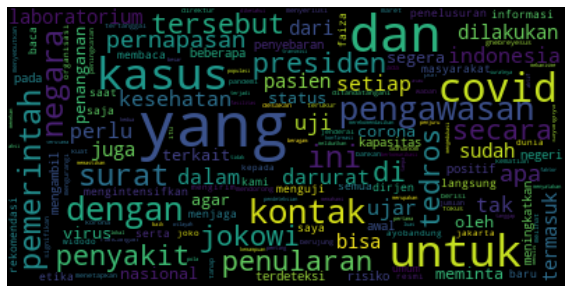

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(max_font_size=45).generate(clean_txt)
plt.figure(figsize=(10,8))

'''plot wordcloud in matplotlib'''

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

###Word Frequency

In [7]:
words_in_article = clean_txt.split() #tokeniasi
words_in_article

['jakarta',
 'ayobandung',
 'com',
 'organisasi',
 'kesehatan',
 'dunia',
 'who',
 'mengirim',
 'surat',
 'resmi',
 'kepada',
 'presiden',
 'joko',
 'widodo',
 'jokowi',
 'surat',
 'yang',
 'ditandatangani',
 'oleh',
 'direktur',
 'jenderal',
 'who',
 'tedros',
 'adhanom',
 'ghebreyesus',
 'tertanggal',
 'maret',
 'itu',
 'berisi',
 'desakan',
 'agar',
 'pemerintah',
 'indonesia',
 'menyeriusi',
 'penanganan',
 'pandemi',
 'covid',
 'oleh',
 'virus',
 'corona',
 'ini',
 'bahkan',
 'who',
 'meminta',
 'jokowi',
 'segera',
 'menetapkan',
 'status',
 'darurat',
 'nasional',
 'terkait',
 'penyebaran',
 'covid',
 'dalam',
 'surat',
 'tersebut',
 'tedros',
 'menyebutkan',
 'setiap',
 'negara',
 'perlu',
 'mengambil',
 'rancangan',
 'yang',
 'kuat',
 'dan',
 'terukur',
 'untuk',
 'mengurangi',
 'penularan',
 'virus',
 'korona',
 'ini',
 'sayangnya',
 'ujar',
 'tedros',
 'who',
 'melihat',
 'ada',
 'kasus',
 'tak',
 'terdeteksi',
 'dalam',
 'tahap',
 'awal',
 'penyebaran',
 'wabah',
 'ini',
 '

In [20]:
import collections
import itertools

# Create counter
counts_no_urls = collections.Counter(words_in_article) #melakukan perhitungan kata dari artikel

counts_no_urls.most_common(20)

[('yang', 23),
 ('who', 17),
 ('dan', 15),
 ('untuk', 11),
 ('kasus', 11),
 ('covid', 9),
 ('dengan', 6),
 ('kontak', 6),
 ('pengawasan', 6),
 ('surat', 5),
 ('pemerintah', 5),
 ('ini', 5),
 ('negara', 5),
 ('presiden', 4),
 ('jokowi', 4),
 ('tedros', 4),
 ('tersebut', 4),
 ('penularan', 4),
 ('secara', 4),
 ('di', 4)]

In [21]:
import pandas as pd

df = pd.DataFrame(counts_no_urls.most_common(20),
                             columns=['words', 'count'])

df.head()

,words,count
0,yang,23
1,who,17
2,dan,15
3,untuk,11
4,kasus,11


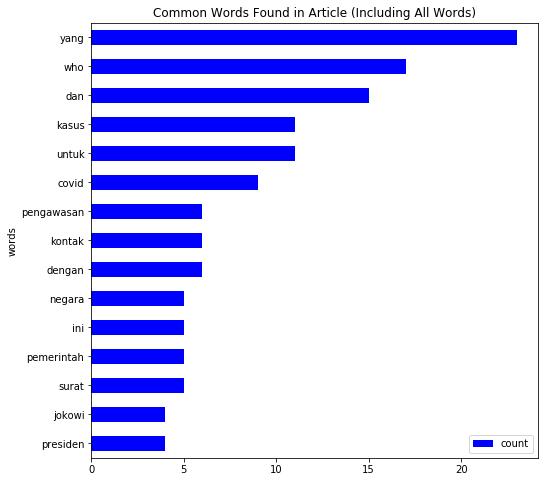

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot horizontal bar graph
df.sort_values(by='count').plot.barh(x='words',
                      y='count',
                      ax=ax,
                      color="blue")

ax.set_title("Common Words Found in Article (Including All Words)")

plt.show()

###Word Frequency after Removing Stopwords

In [11]:
import nltk
from nltk.corpus import stopwords 
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [12]:
stop_words = set(stopwords.words('indonesian'))

# View a few words from the set
list(stop_words)[0:10]

['wah',
 'bukan',
 'terbanyak',
 'kini',
 'kok',
 'terhadapnya',
 'bagian',
 'ditambahkan',
 'sebetulnya',
 'terkira']

In [13]:
new_word_list = [word for word in words_in_article if not word in stop_words]  
new_word_list

['jakarta',
 'ayobandung',
 'com',
 'organisasi',
 'kesehatan',
 'dunia',
 'who',
 'mengirim',
 'surat',
 'resmi',
 'presiden',
 'joko',
 'widodo',
 'jokowi',
 'surat',
 'ditandatangani',
 'direktur',
 'jenderal',
 'who',
 'tedros',
 'adhanom',
 'ghebreyesus',
 'tertanggal',
 'maret',
 'berisi',
 'desakan',
 'pemerintah',
 'indonesia',
 'menyeriusi',
 'penanganan',
 'pandemi',
 'covid',
 'virus',
 'corona',
 'who',
 'jokowi',
 'menetapkan',
 'status',
 'darurat',
 'nasional',
 'terkait',
 'penyebaran',
 'covid',
 'surat',
 'tedros',
 'negara',
 'mengambil',
 'rancangan',
 'kuat',
 'terukur',
 'mengurangi',
 'penularan',
 'virus',
 'korona',
 'sayangnya',
 'tedros',
 'who',
 'terdeteksi',
 'tahap',
 'penyebaran',
 'wabah',
 'berujung',
 'peningkatan',
 'kematian',
 'signifikan',
 'negara',
 'who',
 'mendorong',
 'negara',
 'fokus',
 'pendeteksian',
 'meningkatkan',
 'kapasitas',
 'uji',
 'laboratorium',
 'positif',
 'covid',
 'negara',
 'populasi',
 'kemampuan',
 'fasilitas',
 'kesehata

In [23]:
import collections
import itertools

# Create counter
counts_no_urls = collections.Counter(new_word_list)

counts_no_urls.most_common(20)

[('who', 17),
 ('covid', 9),
 ('kontak', 6),
 ('pengawasan', 6),
 ('surat', 5),
 ('pemerintah', 5),
 ('negara', 5),
 ('presiden', 4),
 ('jokowi', 4),
 ('tedros', 4),
 ('penularan', 4),
 ('penyakit', 4),
 ('pernapasan', 4),
 ('kesehatan', 3),
 ('indonesia', 3),
 ('darurat', 3),
 ('uji', 3),
 ('laboratorium', 3),
 ('pasien', 3),
 ('penanganan', 2)]

In [24]:
import pandas as pd

df = pd.DataFrame(counts_no_urls.most_common(20),
                             columns=['words', 'count'])

df.head()

,words,count
0,who,17
1,covid,9
2,kontak,6
3,pengawasan,6
4,surat,5


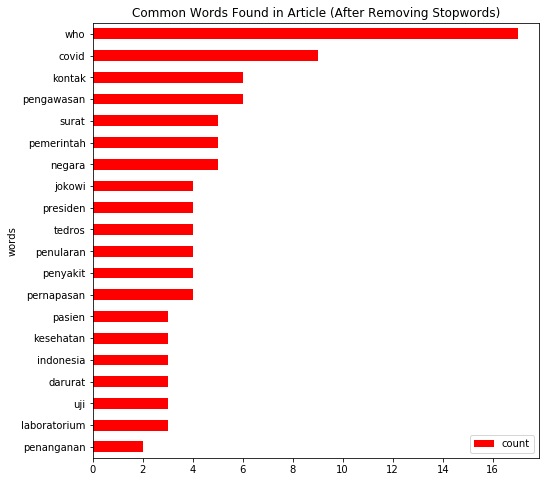

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot horizontal bar graph
df.sort_values(by='count').plot.barh(x='words',
                      y='count',
                      ax=ax,
                      color="red")

ax.set_title("Common Words Found in Article (After Removing Stopwords)")

plt.show()

###Scraping Multiple Pages and Save to TXT

In [0]:
urls = ["https://www.suara.com/news/2020/03/14/051213/kasus-corona-meningkat-indonesia-berpotensi-lockdown-dan-4-berita-lainnya",
       "https://news.detik.com/berita/d-4938668/kasus-corona-di-indonesia-4-meninggal-belum-perlu-lockdown-solo-liburkan-sekolah",]

In [0]:
for url in urls:
    article = Article(url)
    article.download()
    article.parse()
    with open("news.txt","a+") as f:
        txt = article.text
        txt = txt.encode('ascii', 'ignore').decode("utf-8")
        f.write(txt + "\n\n")
        f.close()

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


/content/news.txt

###References



*   https://www.earthdatascience.org/courses/earth-analytics-python/using-apis-natural-language-processing-twitter/calculate-tweet-word-frequencies-in-python/

